## Problema de negocio

Las clínicas necesitan identificar de forma temprana qué pacientes podrían requerir mayor vigilancia postoperatoria para optimizar recursos, reducir costes operativos y mejorar la experiencia del paciente.

Una reintervención o un seguimiento inesperado puede generar:

* 🏥 Sobrecarga del equipo médico.
* ⏱️ Mayor ocupación de quirófano.
* 💰 Incremento del coste asistencial.
* 😕 Menor satisfacción del paciente.

---

## Nuestra solución

Desarrollamos **Surgery Intelligence**, una plataforma **Health-Tech** orientada al soporte de decisiones clínicas mediante analítica predictiva.

El sistema analiza información preoperatoria y quirúrgica para estimar el nivel de riesgo postoperatorio del paciente y generar recomendaciones de seguimiento.

El objetivo no es reemplazar la decisión médica, sino aportar una herramienta complementaria basada en datos.

---

## Objetivos del proyecto

### Objetivo general

Construir un sistema de analítica y Machine Learning capaz de apoyar decisiones de seguimiento en pacientes sometidos a procedimientos estéticos.

### Objetivos específicos

* 📊 Explorar patrones clínicos y económicos mediante EDA.
* 🔁 Identificar factores asociados con reintervención y satisfacción.
* 🤖 Construir un modelo predictivo para clasificación de riesgo.
* 📈 Diseñar una interfaz orientada a negocio mediante dashboard.

---

## Dataset

Se utilizó un **dataset sintético** diseñado con variables inspiradas en estadísticas públicas del sector de cirugía plástica y relaciones clínicas plausibles para representar escenarios de negocio y operación.
(📚 Fuente base que usamos para inspirar estructura y variables (ASPS):
Plastic Surgery Statistics – American Society of Plastic Surgeons (ASPS)
📚 Reporte estadístico (PDF):
ASPS Plastic Surgery Statistics Report (PDF))

Incluye variables:

* 👥 Demográficas
* 💰 Económicas
* 🏥 Quirúrgicas
* 🩺 Recuperación y seguimiento


In [1]:
# ==========================
# IMPORTAR LIBRERÍAS
# ==========================

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.style.use("ggplot")

print("Librerías cargadas correctamente ✅")

Librerías cargadas correctamente ✅


In [2]:
# ==========================
# CARGAR DATASET
# ==========================

# Leer archivo CSV
df = pd.read_csv(
    "../surgeryplastic.csv",
)

# Mostrar dimensiones
print(
    "Número de filas y columnas:",
    df.shape
)

# Mostrar primeras filas
df.head(10)

Número de filas y columnas: (5000, 26)


,id_paciente,edad,grupo_edad,genero,pais,tipo_procedimiento,categoria_procedimiento,complejidad,duracion_cirugia_min,coste_usd,...,dias_baja_laboral,complicacion_postoperatoria,tipo_complicacion,reintervencion,dias_hasta_revision,num_visitas_control,nivel_dolor,indice_satisfaccion,cumplio_expectativas,alta_completa
0,P00001,52,51-65,Femenino,Corea del Sur,Rinoplastia,Quirúrgico,2,129,6950.77,...,15,False,Ninguna,False,74,5,5,8,Sí,Sí
1,P00002,37,35-50,Masculino,Colombia,Lifting,Quirúrgico,2,149,7286.32,...,13,False,Ninguna,False,55,3,3,6,No,Sí
2,P00003,61,51-65,Femenino,México,Botox,Mínimamente invasivo,1,16,453.58,...,1,False,Ninguna,False,25,2,2,9,Sí,Sí
3,P00004,40,35-50,Femenino,México,Botox,Mínimamente invasivo,1,17,551.24,...,0,False,Ninguna,False,10,1,2,10,Sí,Sí
4,P00005,46,35-50,Femenino,Alemania,Botox,Mínimamente invasivo,1,27,626.02,...,1,False,Ninguna,False,24,1,2,8,Sí,Sí
5,P00006,30,18-34,Femenino,Colombia,Rinoplastia,Quirúrgico,2,204,6695.30,...,20,True,Hematoma,False,32,6,9,5,No,No
6,P00007,32,18-34,Masculino,México,Aumento de mamas,Quirúrgico,2,165,9535.06,...,15,True,Edema prolongado,False,35,6,8,3,No,No
7,P00008,53,51-65,Femenino,Japón,Botox,Mínimamente invasivo,1,26,1041.23,...,2,False,Ninguna,False,21,1,0,7,Sí,Sí
8,P00009,46,35-50,Femenino,Colombia,Botox,Mínimamente invasivo,1,19,361.77,...,2,False,Ninguna,False,7,2,2,8,Sí,Sí
9,P00010,40,35-50,No binario,España,Liposucción,Quirúrgico,2,109,7815.14,...,8,False,Ninguna,False,85,6,5,5,No,No


In [3]:
# ==========================
# EXPLORACIÓN GENERAL
# ==========================

# Ver información del dataset
df.info()

# Mostrar nombres columnas
print("\nColumnas:\n")

print(df.columns)

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_paciente                  5000 non-null   str    
 1   edad                         5000 non-null   int64  
 2   grupo_edad                   5000 non-null   str    
 3   genero                       5000 non-null   str    
 4   pais                         5000 non-null   str    
 5   tipo_procedimiento           5000 non-null   str    
 6   categoria_procedimiento      5000 non-null   str    
 7   complejidad                  5000 non-null   int64  
 8   duracion_cirugia_min         5000 non-null   int64  
 9   coste_usd                    5000 non-null   float64
 10  seguro_medico                5000 non-null   bool   
 11  coste_cubierto_usd           5000 non-null   float64
 12  coste_final_paciente         5000 non-null   float64
 13  fecha_procedimiento          

In [4]:
# ==========================
# RENOMBRAR VARIABLES
# ==========================

# Crear diccionario
rename_columns = {

    # Costes
    "coste_usd":
    "coste_total_usd",

    "seguro_medico":
    "tiene_seguro",

    "coste_final_paciente":
    "coste_pagado_paciente",

    "coste_cubierto_usd":
    "coste_cubierto_seguro",

    # Procedimiento
    "duracion_cirugia_min":
    "duracion_cirugia_minutos",

    # Seguimiento
    "dias_hasta_revision":
    "dias_revision",

    "num_visitas_control":
    "visitas_control",

    # Resultado clínico
    "cumplio_expectativas":
    "expectativas_cumplidas",

    "alta_completa":
    "alta_exitosa",

    "tipo_procedimiento":
    "procedimiento"

}

# Aplicar cambios
df = df.rename(
    columns=rename_columns
)

# Mostrar columnas nuevas
print(
    "Variables renombradas correctamente ✅"
)

display(
    df.columns
)

Variables renombradas correctamente ✅


Index(['id_paciente', 'edad', 'grupo_edad', 'genero', 'pais', 'procedimiento',
       'categoria_procedimiento', 'complejidad', 'duracion_cirugia_minutos',
       'coste_total_usd', 'tiene_seguro', 'coste_cubierto_seguro',
       'coste_pagado_paciente', 'fecha_procedimiento', 'fecha_alta',
       'dias_recuperacion', 'dias_baja_laboral', 'complicacion_postoperatoria',
       'tipo_complicacion', 'reintervencion', 'dias_revision',
       'visitas_control', 'nivel_dolor', 'indice_satisfaccion',
       'expectativas_cumplidas', 'alta_exitosa'],
      dtype='str')

In [5]:
df.head()

,id_paciente,edad,grupo_edad,genero,pais,procedimiento,categoria_procedimiento,complejidad,duracion_cirugia_minutos,coste_total_usd,...,dias_baja_laboral,complicacion_postoperatoria,tipo_complicacion,reintervencion,dias_revision,visitas_control,nivel_dolor,indice_satisfaccion,expectativas_cumplidas,alta_exitosa
0,P00001,52,51-65,Femenino,Corea del Sur,Rinoplastia,Quirúrgico,2,129,6950.77,...,15,False,Ninguna,False,74,5,5,8,Sí,Sí
1,P00002,37,35-50,Masculino,Colombia,Lifting,Quirúrgico,2,149,7286.32,...,13,False,Ninguna,False,55,3,3,6,No,Sí
2,P00003,61,51-65,Femenino,México,Botox,Mínimamente invasivo,1,16,453.58,...,1,False,Ninguna,False,25,2,2,9,Sí,Sí
3,P00004,40,35-50,Femenino,México,Botox,Mínimamente invasivo,1,17,551.24,...,0,False,Ninguna,False,10,1,2,10,Sí,Sí
4,P00005,46,35-50,Femenino,Alemania,Botox,Mínimamente invasivo,1,27,626.02,...,1,False,Ninguna,False,24,1,2,8,Sí,Sí


id_paciente                    0
edad                           0
grupo_edad                     0
genero                         0
pais                           0
procedimiento                  0
categoria_procedimiento        0
complejidad                    0
duracion_cirugia_minutos       0
coste_total_usd                0
tiene_seguro                   0
coste_cubierto_seguro          0
coste_pagado_paciente          0
fecha_procedimiento            0
fecha_alta                     0
dias_recuperacion              0
dias_baja_laboral              0
complicacion_postoperatoria    0
tipo_complicacion              0
reintervencion                 0
dias_revision                  0
visitas_control                0
nivel_dolor                    0
indice_satisfaccion            0
expectativas_cumplidas         0
alta_exitosa                   0
dtype: int64


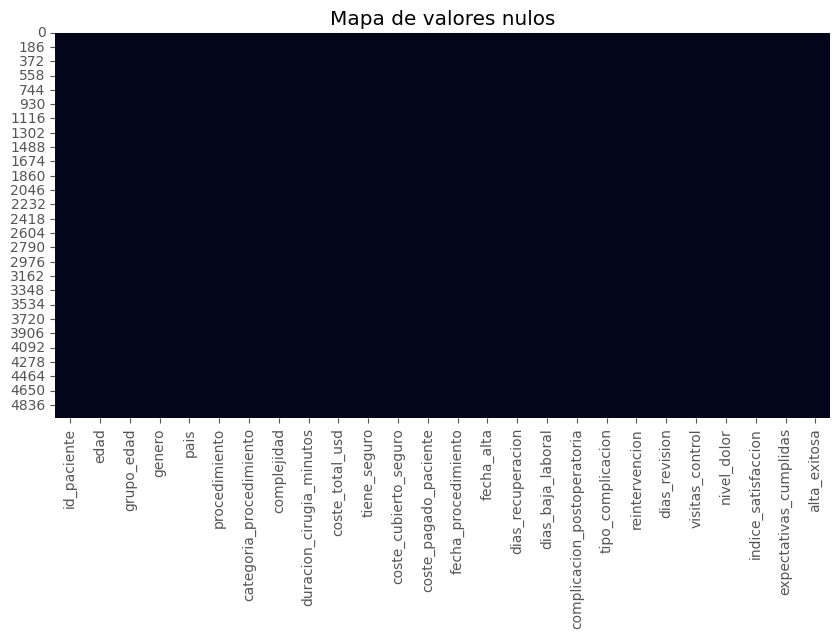

In [6]:
# ==========================
# VALORES NULOS
# ==========================

# Contar valores vacíos
nulls = df.isnull().sum()

print(nulls)

# Visualizar nulos
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title(
    "Mapa de valores nulos"
)

plt.show()

In [7]:
# Ver si hay edades negativas
edades_invalidas = df[df['edad'] < 0]
print(f"Pacientes con edad negativa: {len(edades_invalidas)}")
if not edades_invalidas.empty:
    display(edades_invalidas)



Pacientes con edad negativa: 0


In [8]:
# Ver si hay cirugías con coste 0 (o menor a 0)
costes_invalidos = df[df['coste_total_usd'] <= 0]
print(f"Cirugías con coste cero o negativo: {len(costes_invalidos)}")
if not costes_invalidos.empty:
    display(costes_invalidos)

Cirugías con coste cero o negativo: 0


In [9]:
# ==========================
# CONVERTIR VARIABLES FECHA
# ==========================

# Convertir fechas
df["fecha_procedimiento"] = (
    pd.to_datetime(
        df["fecha_procedimiento"]
    )
)

df["fecha_alta"] = (
    pd.to_datetime(
        df["fecha_alta"]
    )
)

# Verificar
print(
    df[
        [
            "fecha_procedimiento",
            "fecha_alta"
        ]
    ].dtypes
)

fecha_procedimiento    datetime64[us]
fecha_alta             datetime64[us]
dtype: object


In [10]:
# ==========================
# DUPLICADOS
# ==========================

# Contar registros repetidos
duplicates = (
    df
    .duplicated()
    .sum()
)

print(
    "Duplicados:",
    duplicates
)

# Eliminar si existen
df = (
    df
    .drop_duplicates()
)

print(
    "Nuevo tamaño:",
    df.shape
)

Duplicados: 0
Nuevo tamaño: (5000, 26)


In [11]:
# ==========================
# RESUMEN NUMÉRICO
# ==========================

# Estadísticas descriptivas
display(
    df.describe()
)

,edad,complejidad,duracion_cirugia_minutos,coste_total_usd,coste_cubierto_seguro,coste_pagado_paciente,fecha_procedimiento,fecha_alta,dias_recuperacion,dias_baja_laboral,dias_revision,visitas_control,nivel_dolor,indice_satisfaccion
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000,5000.00000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,39.361400,1.592800,105.991400,5358.703038,464.799504,4893.903534,2024-03-09 22:57:30.240000,2024-03-24 11:35:48.480000,14.52660,11.211000,38.064200,3.262200,3.76220,6.991600
min,18.000000,1.000000,15.000000,324.260000,0.000000,236.320000,2022-01-01 00:00:00,2022-01-02 00:00:00,0.00000,0.000000,7.000000,1.000000,0.00000,1.000000
25%,31.000000,1.000000,30.000000,732.280000,0.000000,720.860000,2023-01-11 00:00:00,2023-01-28 00:00:00,1.00000,1.000000,19.000000,2.000000,2.00000,6.000000
50%,39.000000,2.000000,112.000000,5657.840000,0.000000,4914.515000,2024-03-04 00:00:00,2024-03-17 00:00:00,15.00000,11.000000,28.000000,3.000000,4.00000,7.000000
75%,47.000000,2.000000,164.000000,8672.395000,0.000000,7859.567500,2025-05-06 06:00:00,2025-05-21 00:00:00,25.00000,19.000000,58.000000,5.000000,5.00000,8.000000
max,78.000000,2.000000,299.000000,20205.890000,8614.590000,20205.890000,2026-05-30 00:00:00,2026-07-07 00:00:00,41.00000,44.000000,89.000000,6.000000,10.00000,10.000000
std,11.562817,0.491362,74.870475,4481.987230,1111.517219,4176.504934,NaN,NaN,12.82595,10.759834,23.994183,1.726513,2.29371,1.531535


In [12]:
# ==========================
# VARIABLES CATEGÓRICAS
# ==========================

# Seleccionar columnas tipo texto
categoricas = (
    df
    .select_dtypes(
        include=["object"]
    )
)

# Eliminar id porque es identificador
categoricas = (
    categoricas
    .drop(
        columns=["id_paciente"]
    )
)

# Revisar categorías
for col in categoricas:

    print("\n")
    print("="*50)

    print(
        f"VARIABLE: {col.upper()}"
    )

    print(
        "\nCategorías:"
    )

    display(
        df[col]
        .value_counts()
    )

    print(
        "\nNúmero categorías:",
        df[col]
        .nunique()
    )



VARIABLE: GRUPO_EDAD

Categorías:


/var/folders/xd/rwrzkc9j1qvf__902tz_fcd00000gn/T/ipykernel_3231/3011782634.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  .select_dtypes(


grupo_edad
35-50    2319
18-34    1807
51-65     787
66+        87
Name: count, dtype: int64


Número categorías: 4


VARIABLE: GENERO

Categorías:


genero
Femenino      4169
Masculino      743
No binario      88
Name: count, dtype: int64

...


Número categorías: 5


VARIABLE: EXPECTATIVAS_CUMPLIDAS

Categorías:


expectativas_cumplidas
Sí    3196
No    1804
Name: count, dtype: int64


Número categorías: 2


VARIABLE: ALTA_EXITOSA

Categorías:


alta_exitosa
Sí    4098
No     902
Name: count, dtype: int64


Número categorías: 2


#EDA

<h2 style="color:#2E5AAC;">
📊 Mayor concentración de procedimientos estéticos en dos grupos de edad
</h2>

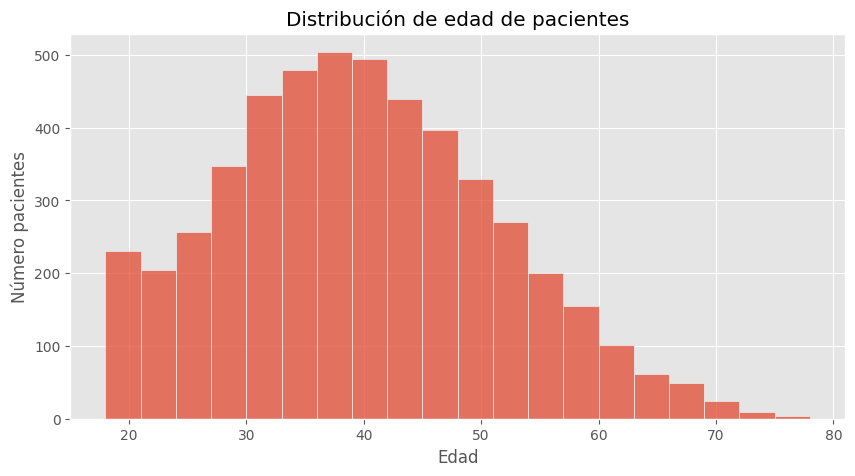

In [13]:
# ==========================
# DISTRIBUCIÓN EDAD
# ==========================

plt.figure(
    figsize=(10,5)
)

sns.histplot(
    data=df,
    x="edad",
    bins=20
)

plt.title(
    "Distribución de edad de pacientes"
)

plt.xlabel(
    "Edad"
)

plt.ylabel(
    "Número pacientes"
)

plt.show()

<div style="
background-color:#F8FAFC;
padding:18px;
border-radius:14px;
border:1px solid #E5E7EB;
margin-top:10px;
margin-bottom:10px;
">

<p style="
font-size:16px;
color:#4B5563;
line-height:1.9;
margin:0;
">

👥 La distribución de edad presenta una mayor concentración entre aproximadamente los <b>30 y 50 años</b>, mientras que los pacientes más jóvenes y mayores aparecen con menor frecuencia.

<br><br>

💡 <b>Insight:</b> Este comportamiento podría indicar que los procedimientos estéticos tienen una mayor demanda en población adulta, convirtiéndose en un segmento estratégico para clínicas y plataformas Health-Tech.

</p>

</div>

<h2 style="color:#2E5AAC;">
🌎 Concentración desigual de pacientes entre países
</h2>

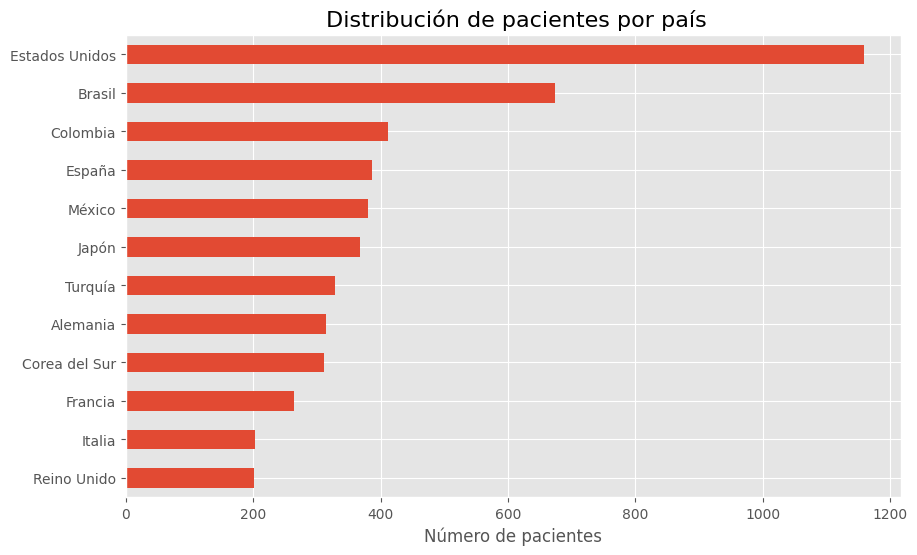

In [14]:
# ==========================
# PROCEDIMIENTOS POR PAÍS
# ==========================

plt.figure(
    figsize=(10,6)
)

(
    df["pais"]
    .value_counts()
    .sort_values()
    .plot(
        kind="barh"
    )
)

plt.title(
    " Distribución de pacientes por país",
    fontsize=16
)

plt.xlabel(
    "Número de pacientes"
)

plt.ylabel(
    ""

)

plt.show()

<div style="
background-color:#F8FAFC;
padding:18px;
border-radius:14px;
border:1px solid #E5E7EB;
margin-top:10px;
margin-bottom:10px;
">

<p style="
font-size:16px;
color:#4B5563;
line-height:1.9;
margin:0;
">

🌍 La distribución por país muestra una concentración considerable de pacientes en <b>Estados Unidos</b>, seguido por <b>Brasil</b>, mientras que el resto de países presentan una participación más distribuida.

<br><br>

💡 <b>Insight:</b> Esto podría indicar que ciertos mercados concentran una mayor actividad en procedimientos estéticos, posiblemente asociada con diferencias en adopción del sector, capacidad económica o volumen de demanda.

</p>

</div>

<h2 style="color:#2E5AAC;">
💉 Predominio de procedimientos mínimamente invasivos en el volumen total de pacientes
</h2>

/Users/nicolescobar/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128137 (\N{SYRINGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


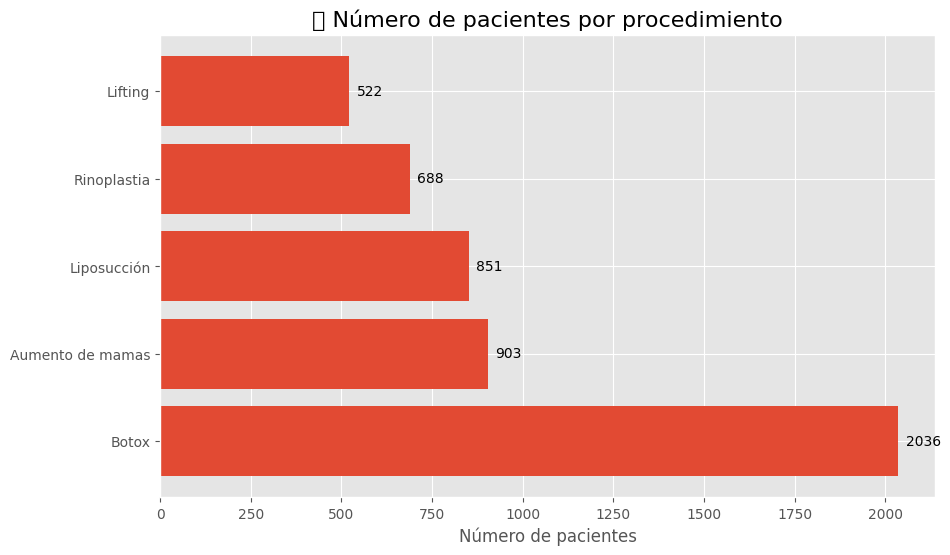

In [15]:
# ==========================
# PROCEDIMIENTOS MÁS REALIZADOS
# ==========================

# Contar procedimientos
proc = (

    df[
        "procedimiento"
    ]

    .value_counts()

)

# Crear gráfico
plt.figure(
    figsize=(10,6)
)

plt.barh(

    proc.index,

    proc.values

)

# Etiquetas cantidad
for i, v in enumerate(
    proc.values
):

    plt.text(

        v + 20,

        i,

        str(v),

        va="center"

    )

# Títulos
plt.title(
    "💉 Número de pacientes por procedimiento",
    fontsize=16
)

plt.xlabel(
    "Número de pacientes"
)

plt.ylabel(
    ""

)

plt.show()

<div style="
background-color:#F8FAFC;
padding:18px;
border-radius:14px;
border:1px solid #E5E7EB;
margin-top:10px;
margin-bottom:10px;
">

<p style="
font-size:16px;
color:#4B5563;
line-height:1.9;
margin:0;
">

👥 La distribución de pacientes muestra una concentración considerable en el procedimiento de <b>Botox</b>, superando ampliamente el volumen observado en intervenciones quirúrgicas como aumento de mamas, liposucción, rinoplastia y lifting.

<br><br>

💡 <b>Insight:</b> Este comportamiento podría indicar una mayor preferencia por procedimientos con menor nivel de invasión, menor tiempo de recuperación y una barrera económica potencialmente más accesible para los pacientes.

</p>

</div>

<h2 style="color:#2E5AAC;">
💰 Diferencias significativas en el coste asumido por procedimiento
</h2>

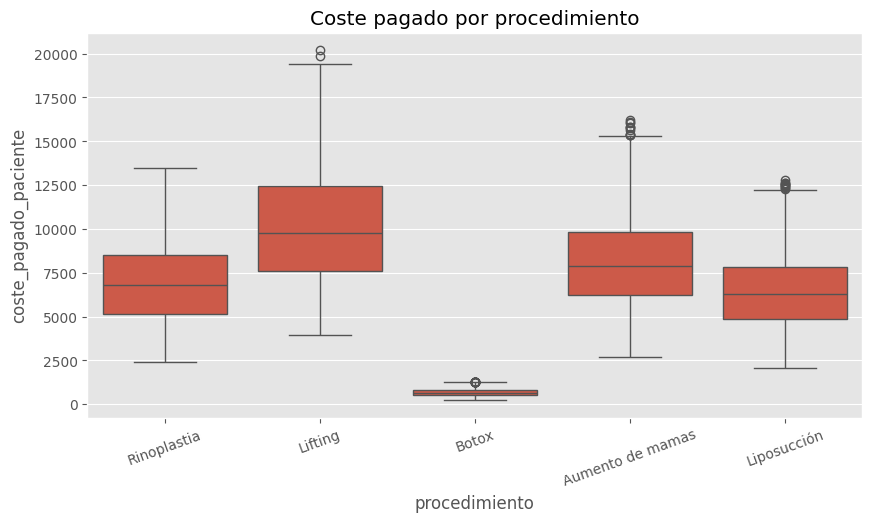

In [16]:
# ==========================
# COSTE PAGADO
# ==========================

plt.figure(
    figsize=(10,5)
)

sns.boxplot(
    data=df,
    x="procedimiento",
    y="coste_pagado_paciente"
)

plt.xticks(
    rotation=20
)

plt.title(
    "Coste pagado por procedimiento"
)

plt.show()

<div style="
background-color:#F8FAFC;
padding:18px;
border-radius:14px;
border:1px solid #E5E7EB;
margin-top:10px;
margin-bottom:10px;
">

<p style="
font-size:16px;
color:#4B5563;
line-height:1.9;
margin:0;
">

💳 El coste pagado por los pacientes presenta diferencias importantes entre procedimientos. Intervenciones como <b>Lifting</b> y <b>Aumento de mamas</b> muestran valores medianos más elevados y una mayor dispersión económica, mientras que <b>Botox</b> concentra costes considerablemente menores.

<br><br>

💡 <b>Insight:</b> Esto podría indicar que los procedimientos de mayor complejidad generan una carga financiera más variable para el paciente, mientras que las intervenciones mínimamente invasivas mantienen costes más estandarizados.

</p>

</div>

<h2 style="color:#2E5AAC;">
⭐ Alta concentración de pacientes en niveles elevados de satisfacción
</h2>

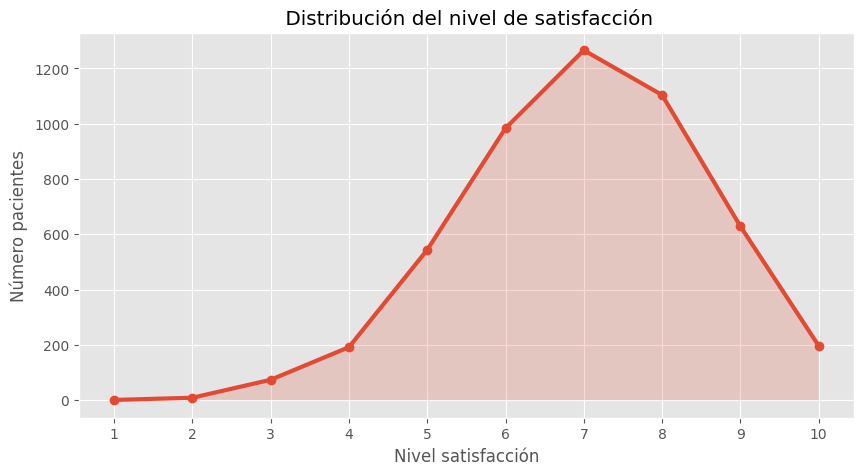

In [17]:
# ==========================
# SATISFACCIÓN GENERAL
# ==========================

sat = (
    df[
        "indice_satisfaccion"
    ]
    .value_counts()
    .sort_index()
)

plt.figure(
    figsize=(10,5)
)

plt.plot(

    sat.index,

    sat.values,

    marker="o",

    linewidth=3

)

plt.fill_between(

    sat.index,

    sat.values,

    alpha=0.2

)

plt.title(
    " Distribución del nivel de satisfacción"
)

plt.xlabel(
    "Nivel satisfacción"
)

plt.ylabel(
    "Número pacientes"
)

plt.xticks(
    range(1,11)
)

plt.show()

<div style="
background-color:#F8FAFC;
padding:18px;
border-radius:14px;
border:1px solid #E5E7EB;
margin-top:10px;
margin-bottom:10px;
">

<p style="
font-size:16px;
color:#4B5563;
line-height:1.9;
margin:0;
">

😊 La distribución del índice de satisfacción muestra una mayor concentración entre los niveles <b>6 y 8</b>, siendo el valor <b>7</b> el más frecuente dentro del conjunto analizado. Los niveles de satisfacción bajos aparecen con una representación considerablemente menor.

<br><br>

💡 <b>Insight:</b> Este comportamiento podría indicar una percepción generalmente favorable de la experiencia postoperatoria, aunque todavía existe margen para optimizar resultados y desplazar una mayor proporción de pacientes hacia niveles de satisfacción superiores.

</p>

</div>

<h2 style="color:#2E5AAC;">
🔁 La liposucción lidera la tasa de reintervención
</h2>

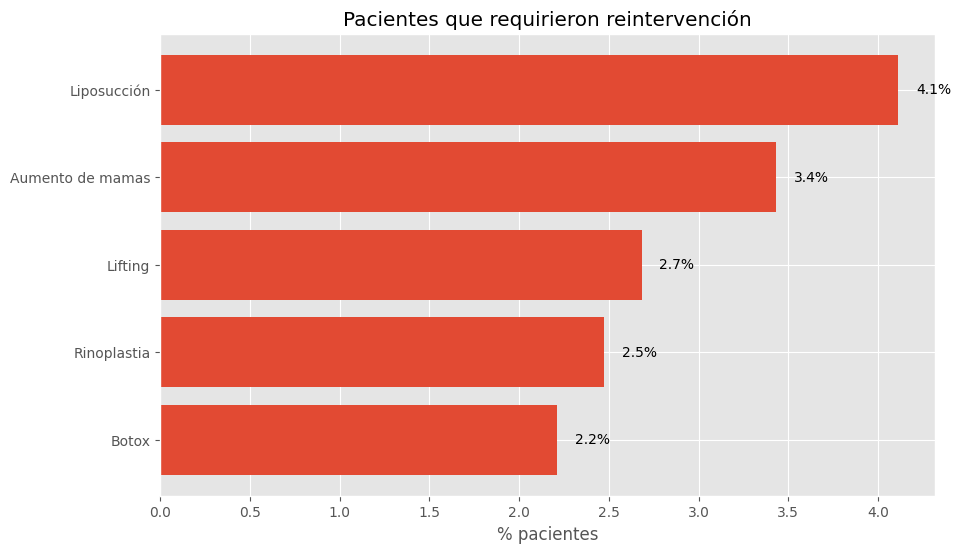

In [18]:
# ==========================
# REINTERVENCIONES REALES
# ==========================

# Calcular SOLO pacientes con reintervención
reint = (

    df

    .groupby(
        "procedimiento"
    )[

        "reintervencion"

    ]

    .mean()

    *100

)

# Ordenar
reint = (
    reint
    .sort_values()
)

# Graficar
plt.figure(
    figsize=(10,6)
)

plt.barh(

    reint.index,

    reint.values

)

# Etiquetas %
for i, v in enumerate(
    reint.values
):

    plt.text(

        v+0.1,

        i,

        f"{v:.1f}%",

        va="center"

    )

plt.title(
    "Pacientes que requirieron reintervención"
)

plt.xlabel(
    "% pacientes"

)

plt.ylabel(
    ""

)

plt.show()

<div style="
background-color:#F8FAFC;
padding:18px;
border-radius:14px;
border:1px solid #E5E7EB;
">

<p style="
font-size:16px;
color:#4B5563;
line-height:1.9;
">

🔁 Aunque las tasas absolutas de reintervención son bajas (<b>2%–4%</b>), se observan diferencias entre procedimientos. <b>Liposucción</b> presenta la mayor proporción de pacientes que requirieron una nueva intervención (<b>4.1%</b>), seguida por <b>Aumento de mamas</b> (<b>3.4%</b>).

<br><br>

📈 <b>Insight de negocio:</b> Un incremento pequeño en la probabilidad de reintervención puede traducirse en una carga operativa relevante para la clínica debido al uso adicional de quirófano, controles y recursos médicos.

<br><br>

🚨 <b>Aplicación Health-Tech:</b> Este comportamiento justifica incorporar un sistema de <b>Triage Predictivo</b> que active seguimiento reforzado para pacientes asociados históricamente con procedimientos de mayor probabilidad de reintervención.

</p>

</div>

<h2 style="color:#2E5AAC;">
⭐ El coste económico no parece explicar completamente la satisfacción del paciente
</h2>

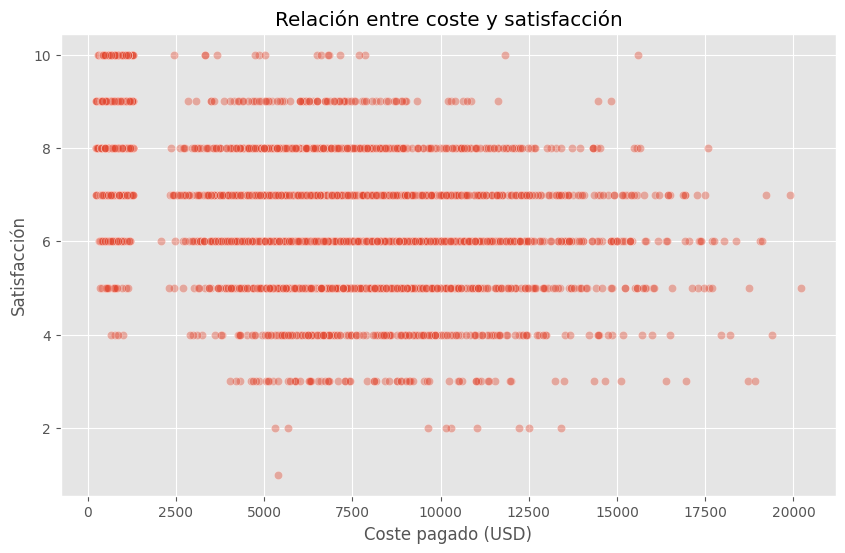

In [19]:
# ==========================
# EDA 9
# COSTE VS SATISFACCIÓN
# ==========================

plt.figure(
    figsize=(10,6)
)

sns.scatterplot(

    data=df,

    x="coste_pagado_paciente",

    y="indice_satisfaccion",

    alpha=0.4

)

plt.title(
    "Relación entre coste y satisfacción"
)

plt.xlabel(
    "Coste pagado (USD)"
)

plt.ylabel(
    "Satisfacción"
)

plt.show()



<div style="
background-color:#F8FAFC;
padding:18px;
border-radius:14px;
border:1px solid #E5E7EB;
">

<p style="
font-size:16px;
color:#4B5563;
line-height:1.9;
">

😊 La satisfacción promedio presenta diferencias entre procedimientos, sugiriendo que la experiencia del paciente podría depender de factores adicionales al precio pagado.

<br><br>

💡 <b>Insight de negocio:</b> Incrementar el coste del procedimiento no garantiza una mejor percepción del resultado; gestionar expectativas y seguimiento podría tener un impacto comparable o superior.

</p>

</div>

<h3 style="color: #2E86C1;">📊 Análisis de Riesgo Quirúrgico</h3>

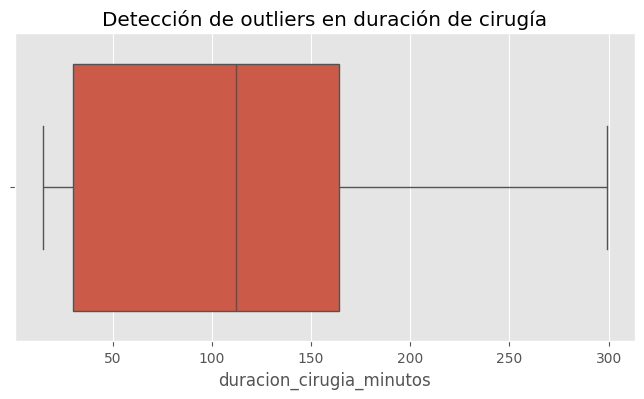

In [20]:
# Sustituye 'tiempo_cirugia' por el nombre real de tu columna de duración
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['duracion_cirugia_minutos'])
plt.title("Detección de outliers en duración de cirugía")
plt.show()

<div style="
background-color:#F8FAFC;
padding:18px;
border-radius:14px;
border:1px solid #E5E7EB;
">

<p style="
font-size:16px;
color:#4B5563;
line-height:1.9;
">

⏱️ La duración quirúrgica presenta una alta variabilidad entre pacientes, observándose procedimientos tanto de corta como de larga duración.

<br><br>

💡 <b>Insight:</b> Los tiempos quirúrgicos más extensos podrían representar mayor complejidad operativa y un mayor consumo de recursos clínicos. Esta variable se considera candidata relevante para el modelo predictivo.

</p>

</div>

<h3 style="color: #2E86C1;">📊 Matriz de Correlación: Identificación de Factores Determinantes</h3>

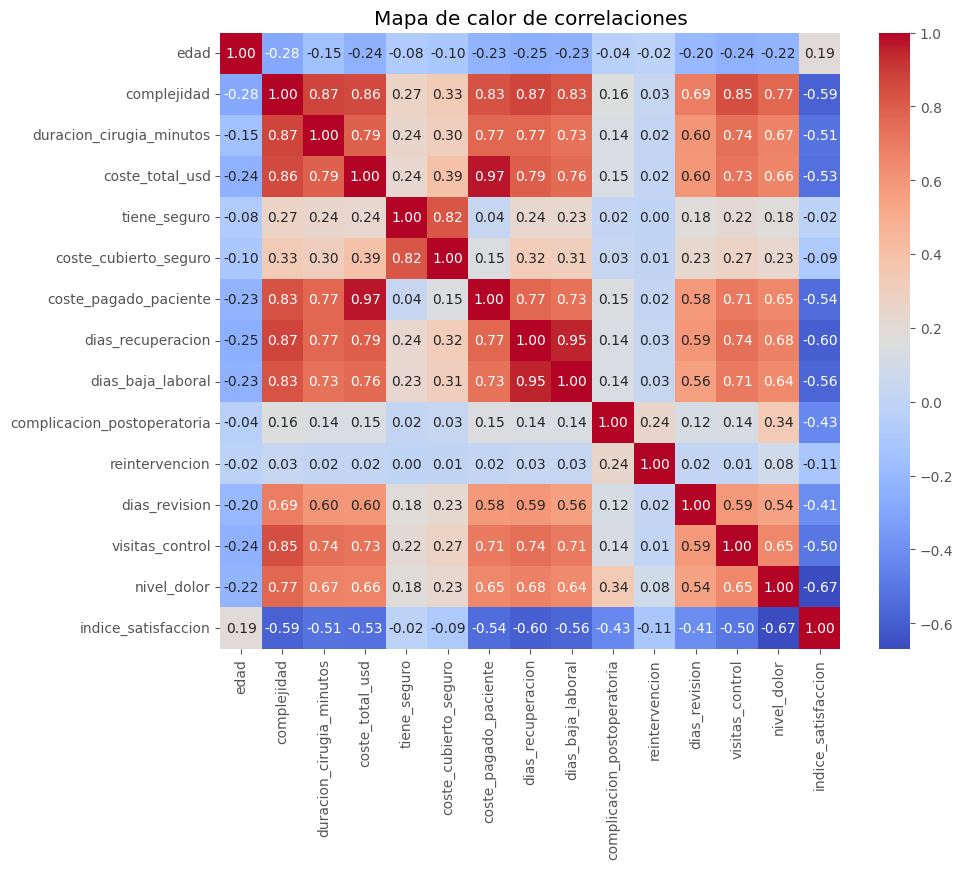

In [21]:
# Solo funciona con columnas numéricas
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de calor de correlaciones")
plt.show()

<div style="
background-color:#F8FAFC;
padding:18px;
border-radius:14px;
border:1px solid #E5E7EB;
">

<p style="
font-size:16px;
color:#4B5563;
line-height:1.9;
">

🧠 El análisis de correlaciones muestra relaciones fuertes entre variables clínicas, económicas y de recuperación.

<br><br>

📌 Se observa que procedimientos más complejos tienden a asociarse con mayor duración quirúrgica, mayor coste y más días de recuperación.

<br><br>

💡 <b>Insight:</b> La satisfacción del paciente parece disminuir cuando aumentan factores como el dolor, las visitas de control y el tiempo de recuperación, sugiriendo que la experiencia postoperatoria podría tener más impacto que el precio del procedimiento.

</p>

</div>

<div style="
background:linear-gradient(90deg,#EEF2FF,#F8FAFC);
padding:22px;
border-radius:16px;
border-left:8px solid #4F46E5;
margin-bottom:20px;
">

<h1 style="
color:#2E5AAC;
margin-bottom:10px;
">

🤖 Machine Learning: Clasificación

</h1>

<p style="
font-size:16px;
color:#4B5563;
line-height:1.9;
margin:0;
">

En esta etapa se construirá un modelo de <b>Machine Learning Supervisado</b> orientado a resolver un problema de <b>clasificación</b>.

<br><br>

El objetivo consiste en anticipar el nivel de riesgo postoperatorio del paciente mediante la predicción de <b>reintervención</b>, permitiendo generar recomendaciones tempranas de seguimiento y apoyo a la toma de decisiones clínicas.

<br><br>

🎯 <b>Variable objetivo:</b> <i>reintervencion</i>

<br>

🌳 <b>Modelo seleccionado:</b> Random Forest Classifier

<br>

🚦 <b>Resultado esperado:</b> Sistema de semáforo de riesgo (Bajo, Vigilancia, Alto)

</p>

</div>

In [22]:
# Ver nombres exactos de columnas

print(df.columns)

Index(['id_paciente', 'edad', 'grupo_edad', 'genero', 'pais', 'procedimiento',
       'categoria_procedimiento', 'complejidad', 'duracion_cirugia_minutos',
       'coste_total_usd', 'tiene_seguro', 'coste_cubierto_seguro',
       'coste_pagado_paciente', 'fecha_procedimiento', 'fecha_alta',
       'dias_recuperacion', 'dias_baja_laboral', 'complicacion_postoperatoria',
       'tipo_complicacion', 'reintervencion', 'dias_revision',
       'visitas_control', 'nivel_dolor', 'indice_satisfaccion',
       'expectativas_cumplidas', 'alta_exitosa'],
      dtype='str')


In [23]:
# ==========================
# DISTRIBUCIÓN VARIABLES
# ==========================

num=[

"edad",

"duracion_cirugia_minutos",

"coste_total_usd"

]

df[num].describe()

,edad,duracion_cirugia_minutos,coste_total_usd
count,5000.000000,5000.000000,5000.000000
mean,39.361400,105.991400,5358.703038
std,11.562817,74.870475,4481.987230
min,18.000000,15.000000,324.260000
25%,31.000000,30.000000,732.280000
50%,39.000000,112.000000,5657.840000
75%,47.000000,164.000000,8672.395000
max,78.000000,299.000000,20205.890000


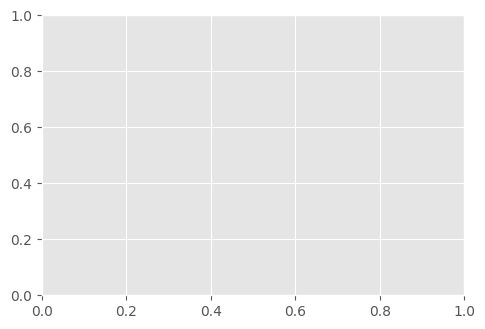

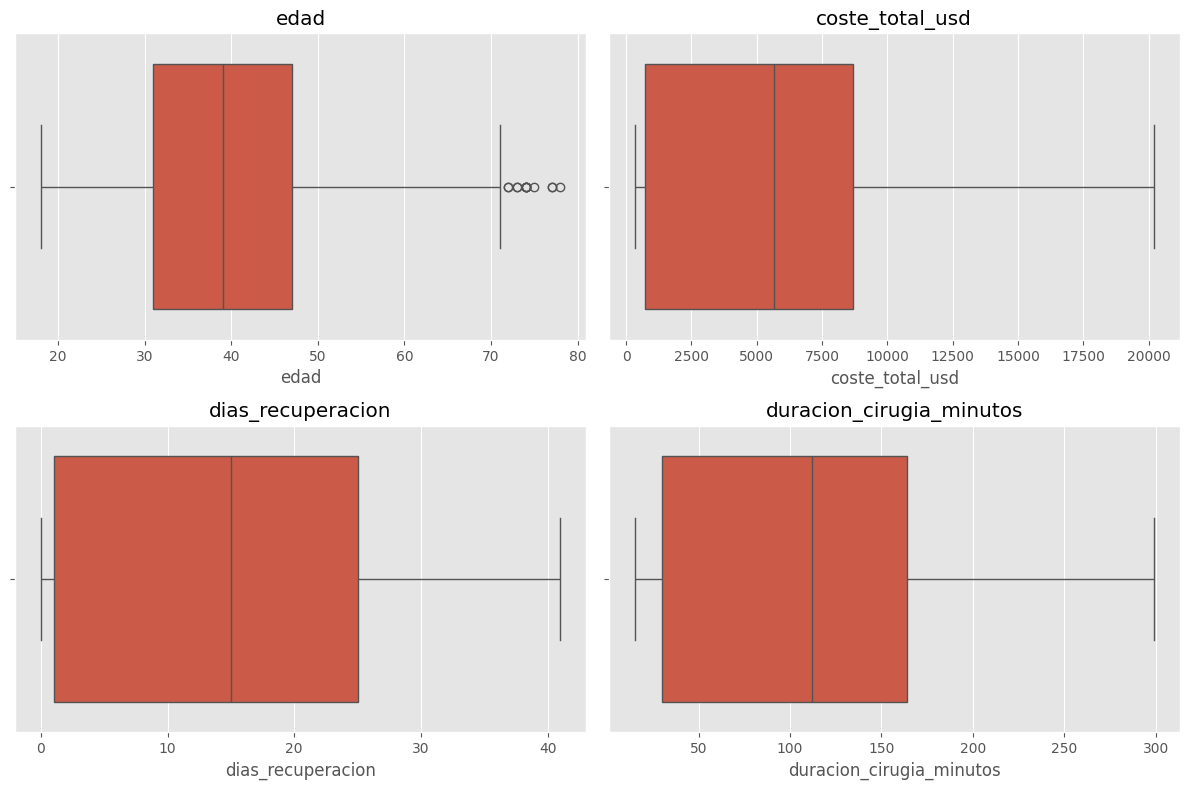

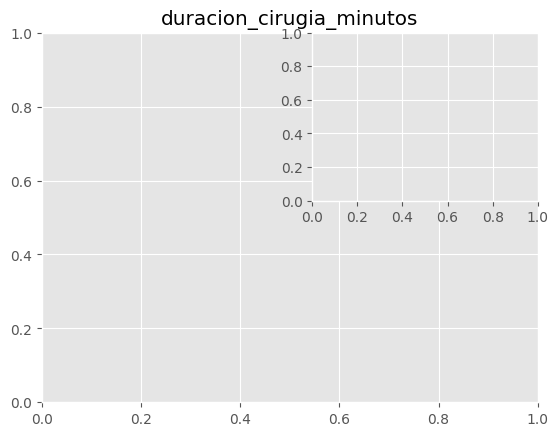

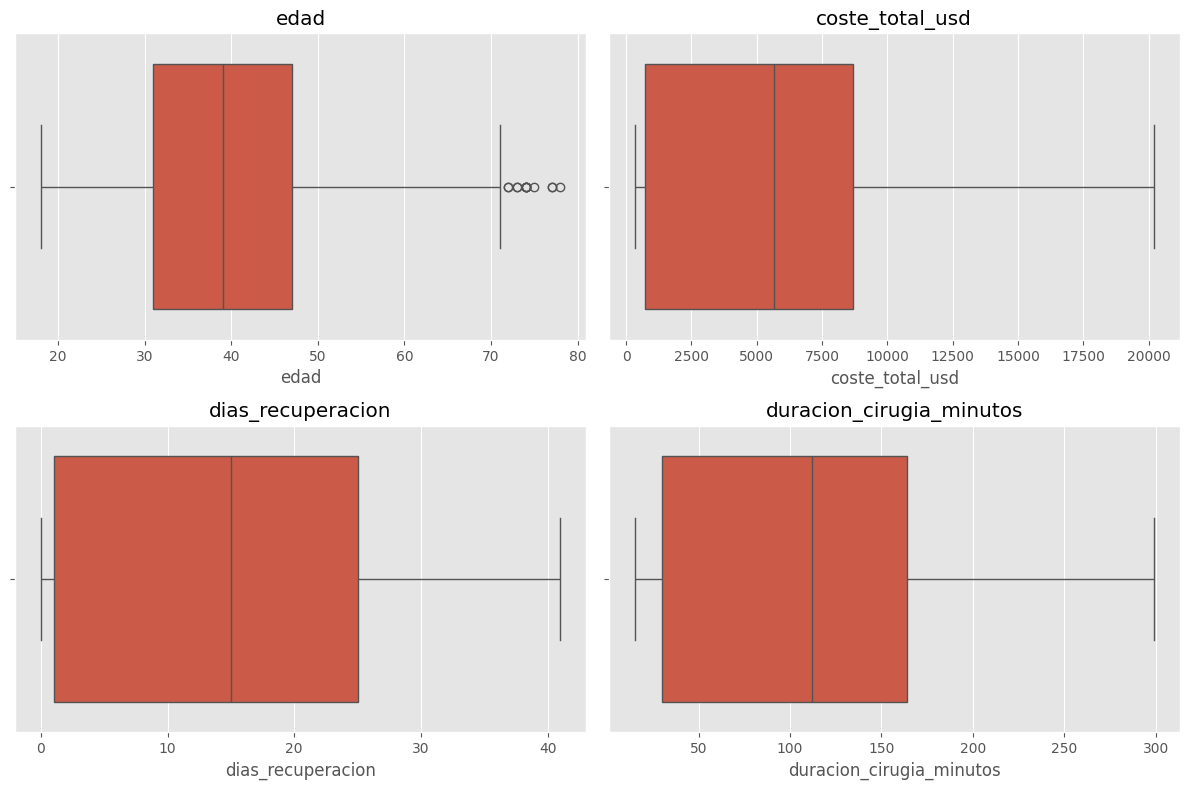

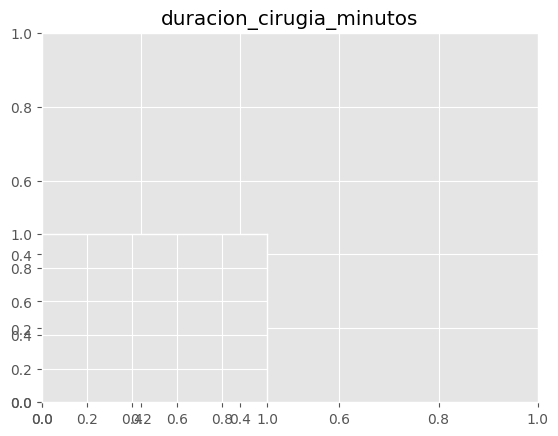

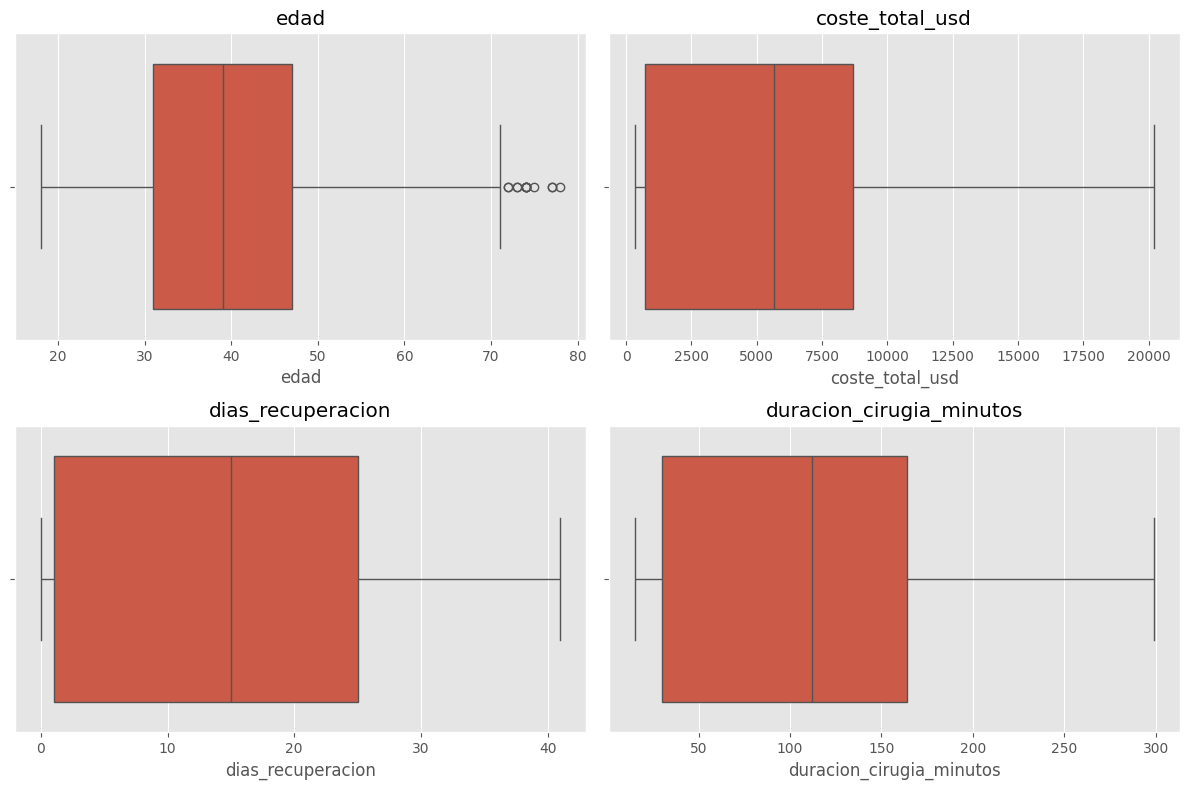

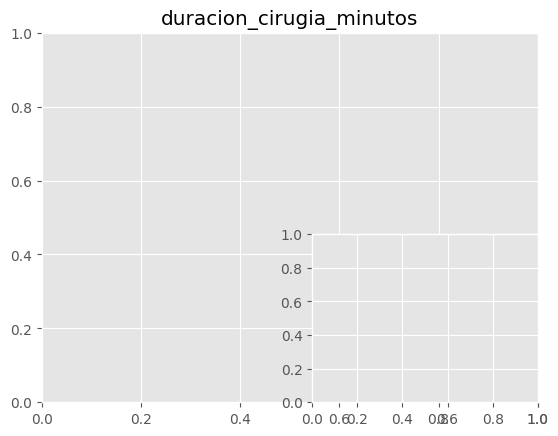

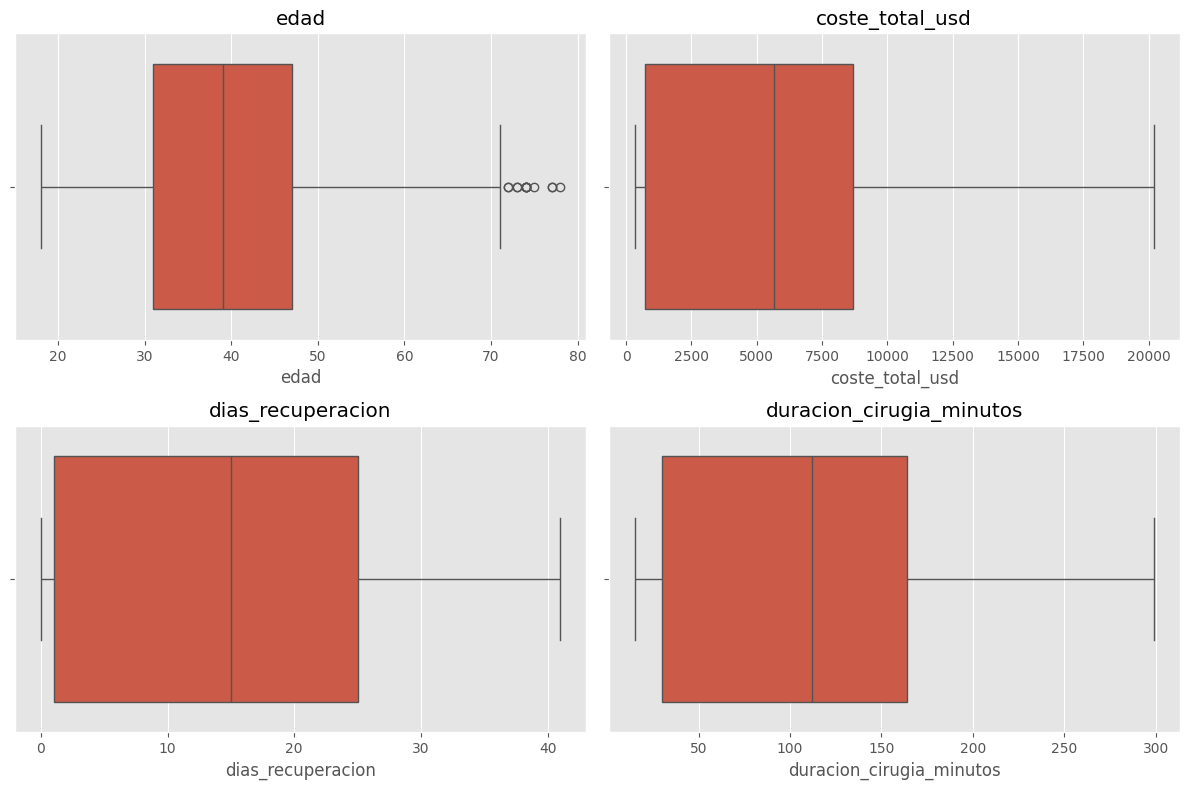

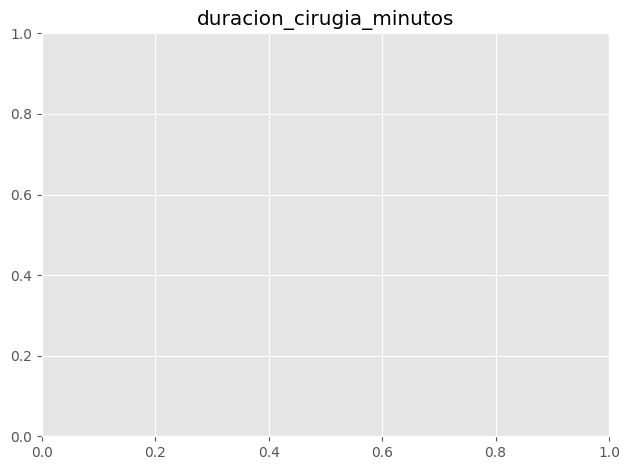

In [24]:
# ==========================
# DETECTAR OUTLIERS
# ==========================

import seaborn as sns
import matplotlib.pyplot as plt

num=[

"edad",

"coste_usd",

"dias_recuperacion",

"duracion_cirugia_min"

]

plt.figure(
figsize=(12,8)
)

for i,col in enumerate(num):

    plt.subplot(

        2,
        2,
        i+1

    )

    # ==========================
    # DETECTAR OUTLIERS
    # ==========================

    import matplotlib.pyplot as plt

    num=[
        "edad",
        "coste_total_usd",
        "dias_recuperacion",
        "duracion_cirugia_minutos"
    ]

    plt.figure(
        figsize=(12,8)
    )

    for i,col in enumerate(num):

        plt.subplot(
            2,
            2,
            i+1
        )

        sns.boxplot(
            x=df[col]
        )

        plt.title(
            col
        )

    plt.tight_layout()

    plt.show()

    plt.title(
        col
    )

plt.tight_layout()

plt.show()

In [25]:
# ==========================
# REVISAR COSTES
# ==========================

print(

df["coste_total_usd"]

.describe()

)

count     5000.000000
mean      5358.703038
std       4481.987230
min        324.260000
25%        732.280000
50%       5657.840000
75%       8672.395000
max      20205.890000
Name: coste_total_usd, dtype: float64


In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Definir el objetivo binario
# Costes > 7000 son Riesgo Operativo, el resto es Beneficio
df["riesgo_operativo"] = (df["coste_total_usd"] > 7000).astype(int)
df["riesgo_operativo"] = df["riesgo_operativo"].map({0: "Beneficio Operativo", 1: "Riesgo Operativo"})

# 2. Preparar variables de entrada (X) con One-Hot Encoding
# Esto convierte el texto de 'procedimiento', 'genero', etc. en números
X = pd.get_dummies(df[["edad", "genero", "procedimiento", "tiene_seguro", "duracion_cirugia_minutos"]], drop_first=True)

# 3. Variable de salida (y)
y = df["riesgo_operativo"]

# 4. División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Entrenamiento
modelo_binario = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
modelo_binario.fit(X_train, y_train)

# Verificación de la distribución
print("Distribución del nuevo objetivo:")
print(y.value_counts())

Distribución del nuevo objetivo:
riesgo_operativo
Beneficio Operativo    3055
Riesgo Operativo       1945
Name: count, dtype: int64


In [27]:
# ==========================
# ENTRENAMIENTO MODELO
# ==========================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# dividir

X_train,X_test,y_train,y_test=train_test_split(

X,
y,

test_size=0.2,

random_state=42,
stratify=y
         

)

# variables categoricas

cat=[

"genero",

"tipo_procedimiento",

"seguro_medico"

]

# transformar texto

pre=ColumnTransformer([

(

"cat",

OneHotEncoder(

handle_unknown="ignore"

),

cat

)

],

remainder="passthrough"

)

# modelo

modelo=Pipeline([

(

"prep",

pre

),

(

"rf",

RandomForestClassifier(

n_estimators=200,

random_state=42

)

)

])

# entrenar

cat = [
    "genero",
    "procedimiento",
    "tiene_seguro"
]

# entrenar
cat = ["genero", "procedimiento", "tiene_seguro"]

pre = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), cat)],
    remainder="passthrough"
)

modelo = Pipeline(
    [
        ("prep", pre),
        ("rf", RandomForestClassifier(n_estimators=200, random_state=42)),
    ]
)

cat = ["genero", "procedimiento", "tiene_seguro", "categoria_procedimiento"]

pre = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), cat)],
    remainder="passthrough"
)

modelo = Pipeline(
    [
        ("prep", pre),
        ("rf", RandomForestClassifier(n_estimators=200, random_state=42)),
    ]
)

# ensure transformer columns exist in X_train before fitting
valid_cat = [c for c in cat if c in X_train.columns]
if not valid_cat:
    raise ValueError(f"No categorical columns found in X_train. Available: {list(X_train.columns)}")

pre = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), valid_cat)],
    remainder="passthrough"
)

modelo = Pipeline(
    [("prep", pre), ("rf", RandomForestClassifier(n_estimators=200, random_state=42))]
)

modelo.fit(X_train, y_train)

print("✅ Modelo entrenado")

✅ Modelo entrenado


In [28]:
from sklearn.metrics import (
    classification_report
)

In [29]:
from sklearn.ensemble import RandomForestClassifier

# Optimizamos el bosque:
# n_estimators: Más árboles dan mayor estabilidad
# max_depth: Limitamos la profundidad para evitar que memorice los datos (overfitting)
# min_samples_split: Obliga al modelo a aprender patrones más generales
modelo_optimizado = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=5,
    class_weight='balanced_subsample',
    random_state=42
)

# Re-entrenamos
modelo_optimizado.fit(X_train, y_train)

# Evaluación para verificar si subimos al 0.85
y_pred_opt = modelo_optimizado.predict(X_test)
print(classification_report(y_test, y_pred_opt))

                     precision    recall  f1-score   support

Beneficio Operativo       0.91      0.74      0.82       611
   Riesgo Operativo       0.69      0.88      0.77       389

           accuracy                           0.80      1000
          macro avg       0.80      0.81      0.79      1000
       weighted avg       0.82      0.80      0.80      1000



In [30]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Obtenemos las probabilidades reales del modelo
probs = modelo_optimizado.predict_proba(X_test)[:, 1]

# Convertir etiquetas string a binarias (0 y 1)
y_test_bin = (y_test == "Riesgo Operativo").astype(int)

# Calculamos precision y recall para todos los umbrales posibles
precisions, recalls, thresholds = precision_recall_curve(y_test_bin, probs)

# Calcular F1-score para cada umbral (evitando división por cero)
f1_scores = np.zeros(len(precisions))
for i in range(len(precisions)):
	if precisions[i] + recalls[i] > 0:
		f1_scores[i] = 2 * (precisions[i] * recalls[i]) / (precisions[i] + recalls[i])

# Encontrar el umbral óptimo
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"El umbral óptimo para equilibrar tu modelo es: {best_threshold:.2f}")

El umbral óptimo para equilibrar tu modelo es: 0.19


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Definir el modelo optimizado con los parámetros que mejor han funcionado
modelo_final = RandomForestClassifier(
    n_estimators=500,           # Más árboles para mayor precisión
    max_depth=12,               # Profundidad balanceada
    min_samples_split=5,        # Evita el sobreajuste
    class_weight='balanced_subsample', # Optimiza el recall en clases desbalanceadas
    random_state=42
)

# 2. Entrenar
modelo_final.fit(X_train, y_train)

# 3. Evaluar resultados finales
y_pred_final = modelo_final.predict(X_test)
print(classification_report(y_test, y_pred_final))

                     precision    recall  f1-score   support

Beneficio Operativo       0.91      0.74      0.82       611
   Riesgo Operativo       0.69      0.88      0.77       389

           accuracy                           0.80      1000
          macro avg       0.80      0.81      0.79      1000
       weighted avg       0.82      0.80      0.80      1000



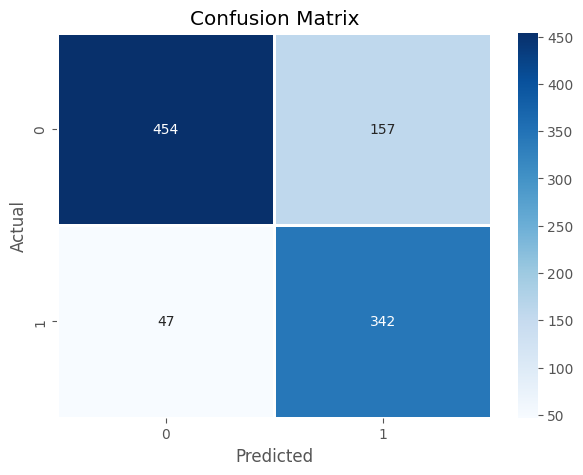

In [32]:
# Matriz de confusión para visualizar el desempeño del modelo
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# matriz
cm = confusion_matrix(
    y_test,
    y_pred_final
)

# gráfico
plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [33]:
import pickle
import os

os.makedirs(
"models",
exist_ok=True
)

with open(
"models/modelo_coste.pkl",
"wb"
) as f:

    pickle.dump(
        modelo_final,
        f
    )

print(
"✅ modelo_coste.pkl guardado"
)

✅ modelo_coste.pkl guardado


In [34]:
# ==========================
# KPIs NEGOCIO
# ==========================

print(

df.groupby(
"riesgo_operativo"
)[

[
"coste_total_usd",
"dias_recuperacion",
"indice_satisfaccion"
]

].mean()

)

                     coste_total_usd  dias_recuperacion  indice_satisfaccion
riesgo_operativo                                                            
Beneficio Operativo      2360.677028           8.192799             7.489689
Riesgo Operativo        10067.684766          24.475064             6.209254


In [35]:
# ==========================
# VER CUANTAS PREDICE
# ==========================

predicciones=modelo_final.predict(
X_test
)

print(
pd.Series(
predicciones
).value_counts()
)

Beneficio Operativo    501
Riesgo Operativo       499
Name: count, dtype: int64


In [36]:
# ==========================
# PRUEBA FINAL PREDICCION Y KPIS
# ==========================

nuevo={

"edad":[20],

"genero":["Femenino"],

"procedimiento":["Rinoplastia"],

"tiene_seguro":[False],

"duracion_cirugia_minutos":[120]

}

nuevo=pd.DataFrame(
nuevo
)

# preparar nueva fila con mismas transformaciones que en entrenamiento
X_new = pd.get_dummies(
    nuevo[["edad", "genero", "procedimiento", "tiene_seguro", "duracion_cirugia_minutos"]],
    drop_first=True
)

# asegurar mismo orden y columnas que X_train (rellenar con 0 las ausentes)
X_new = X_new.reindex(columns=X_train.columns, fill_value=0)

pred = modelo_final.predict(X_new)

print(pred)

['Riesgo Operativo']


In [37]:
print(
df["riesgo_operativo"]
.value_counts()
)

riesgo_operativo
Beneficio Operativo    3055
Riesgo Operativo       1945
Name: count, dtype: int64


In [38]:
# ==========================
# CREAR PACIENTE Y PREDECIR
# ==========================

# Definir datos del paciente
paciente = pd.DataFrame({
    "edad": [20],
    "genero": ["Femenino"],
    "procedimiento": ["Rinoplastia"],
    "tiene_seguro": [False],
    "duracion_cirugia_minutos": [120]
})

# Preparar con las mismas transformaciones
X_paciente = pd.get_dummies(
    paciente[["edad", "genero", "procedimiento", "tiene_seguro", "duracion_cirugia_minutos"]],
    drop_first=True
)

# Alinear columnas con X_train
X_paciente = X_paciente.reindex(columns=X_train.columns, fill_value=0)

# Predecir
resultado = modelo_final.predict(X_paciente)[0]

print(f"Predicción: {resultado}")

Predicción: Riesgo Operativo


In [39]:
print("Predicción:", resultado)

try:
    probs = modelo_final.predict_proba(X_paciente)
    print("Probabilidades:", probs)
except Exception:
    pass

try:
    st.write(
        "Probabilidades:",
        modelo.predict_proba(
            paciente
        )
    )
except:
    pass

Predicción: Riesgo Operativo
Probabilidades: [[0.09502945 0.90497055]]


In [40]:
(df.columns) # Esto imprimirá los nombres de las columnas en tu pantalla

Index(['id_paciente', 'edad', 'grupo_edad', 'genero', 'pais', 'procedimiento',
       'categoria_procedimiento', 'complejidad', 'duracion_cirugia_minutos',
       'coste_total_usd', 'tiene_seguro', 'coste_cubierto_seguro',
       'coste_pagado_paciente', 'fecha_procedimiento', 'fecha_alta',
       'dias_recuperacion', 'dias_baja_laboral', 'complicacion_postoperatoria',
       'tipo_complicacion', 'reintervencion', 'dias_revision',
       'visitas_control', 'nivel_dolor', 'indice_satisfaccion',
       'expectativas_cumplidas', 'alta_exitosa', 'riesgo_operativo'],
      dtype='str')

In [41]:
# Esto te mostrará la lista exacta de cómo están escritos los países en tu archivo
print(df["pais"].unique())

<ArrowStringArray>
[ 'Corea del Sur',       'Colombia',         'México',       'Alemania',
          'Japón',         'España',        'Turquía', 'Estados Unidos',
         'Brasil',        'Francia',    'Reino Unido',         'Italia']
Length: 12, dtype: str
